In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
os.chdir("/Users/AlanHDLR/Desktop")


In [4]:
pima = pd.read_csv("diabetes.csv")
pima

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
col_names = ["pregnant", "glucose", "bp", "skin", "insulin", "bmi", "pedigree", "age", "label"]
pima = pd.read_csv("diabetes.csv", header = None, names = col_names)
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


In [7]:
# Eliminar los ancabezados anteriores
df = pima.iloc[1:,:]
df

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,0,36.8,0.34,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,0,0,30.1,0.349,47,1


In [9]:
# Seleccion de caracteristicas
feature_cols = ["pregnant", "glucose", "bp", "insulin", "bmi", "pedigree", "age"]
X = df[feature_cols]
y = df.label

# Bosques aleatorios (Random Forest)

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
# CReación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [16]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 1)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [18]:
# Score F1 para el grupo de entrenamiento (training)
rf.score(X_train, y_train)

1.0

In [20]:
# Score F1 para el grupo de entrenamiento (testing)
rf.score(X_test, y_test)

0.7987012987012987

In [22]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        99
           1       0.73      0.69      0.71        55

    accuracy                           0.80       154
   macro avg       0.78      0.77      0.78       154
weighted avg       0.80      0.80      0.80       154



In [58]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importance(df, model):
    n_features = feature_cols
    plt.barh(n_features, model.feature_importances_, align="center")
    plt.xlabel("Importancia de las variables")
    plt.ylabel("Caracteristicas")
    plt.show()

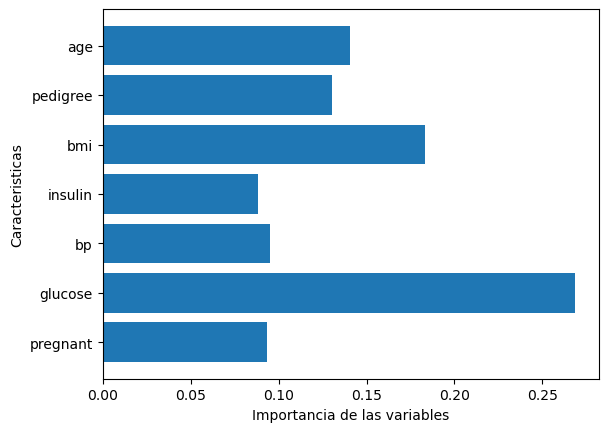

In [60]:
# Que tan importante fue cada variable para pornosticar el resultado
plot_feature_importance(df, rf)

# Potenciación (Bosting)

## Gradient boosted trees

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

In [40]:
# CReación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [46]:
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1) # 100 árboles de profundidad de 3 (Default)
gbt.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [48]:
# Score F1 para el grupo de entrenamiento
gbt.score(X_train, y_train)

0.9104234527687296

In [50]:
# Score F1 para el grupo de prueba
gbt.score(X_test, y_test)

0.8051948051948052

In [52]:
# Estadisticas de desempeño
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        99
           1       0.77      0.65      0.71        55

    accuracy                           0.81       154
   macro avg       0.79      0.77      0.78       154
weighted avg       0.80      0.81      0.80       154



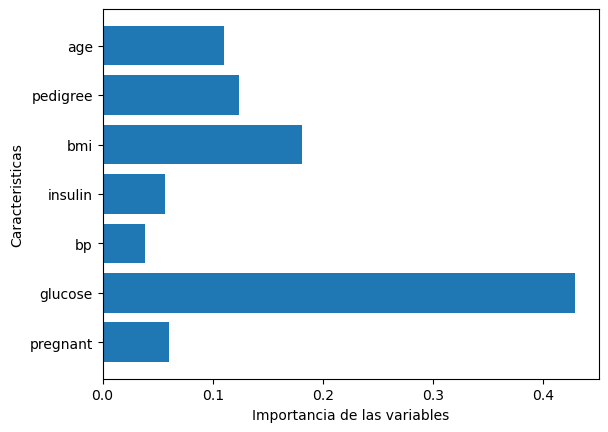

In [62]:
plot_feature_importance(df, gbt)

In [66]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1, max_depth = 2) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))


Training F1 Score: , 0.8452768729641694
Testing F1 Score: , 0.8116883116883117


In [68]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86        99
           1       0.80      0.64      0.71        55

    accuracy                           0.81       154
   macro avg       0.81      0.77      0.78       154
weighted avg       0.81      0.81      0.81       154



In [1]:
plot_feature_importance(df, gbt)

NameError: name 'plot_feature_importance' is not defined

# AdaBoost Classifier

In [75]:
from sklearn.ensemble import AdaBoostClassifier

In [77]:
# Creación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [79]:
# AdaBoost usa árboles de decisión como clasificador por Default
abc = AdaBoostClassifier(n_estimators = 50, learning_rate = 1)

# Entrenamiento del clasificador AdaBoost
model = abc.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        99
           1       0.71      0.67      0.69        55

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.78      0.79      0.78       154



In [87]:
# Utilización de SVM como clasificador para AdaBoost
from sklearn.svm import SVC
svc = SVC(probability = True, kernel = "linear")

In [97]:
# Creación del objeto de clasificación AdaBoost
abc = AdaBoostClassifier(n_estimators = 50, estimator = svc, learning_rate = 1)

model = abc.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      1.00      0.78        99
           1       0.00      0.00      0.00        55

    accuracy                           0.64       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.41      0.64      0.50       154

